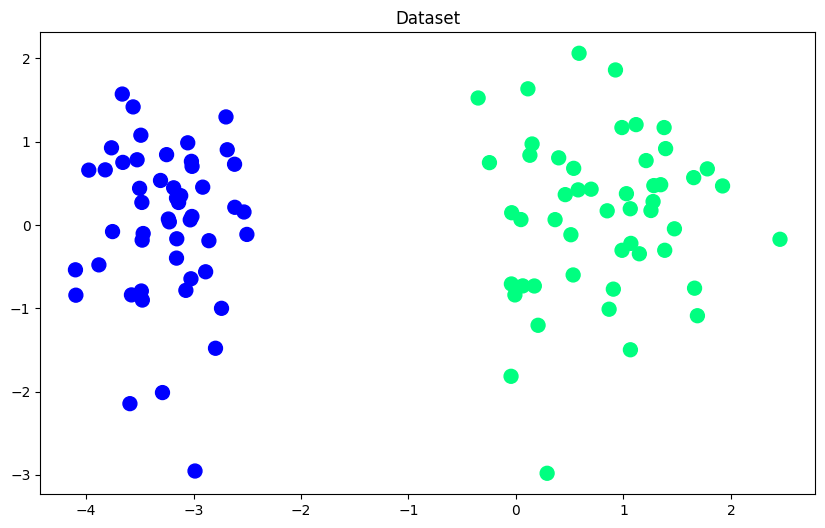

Sklearn coefficients (w1, w2): [[6.16133467 0.42668242]]
Sklearn intercept (bias): [7.89840729]
Manual GD coefficients (w1, w2): [4.83926872 0.21182255]
Manual GD intercept (bias): 5.83338864905325


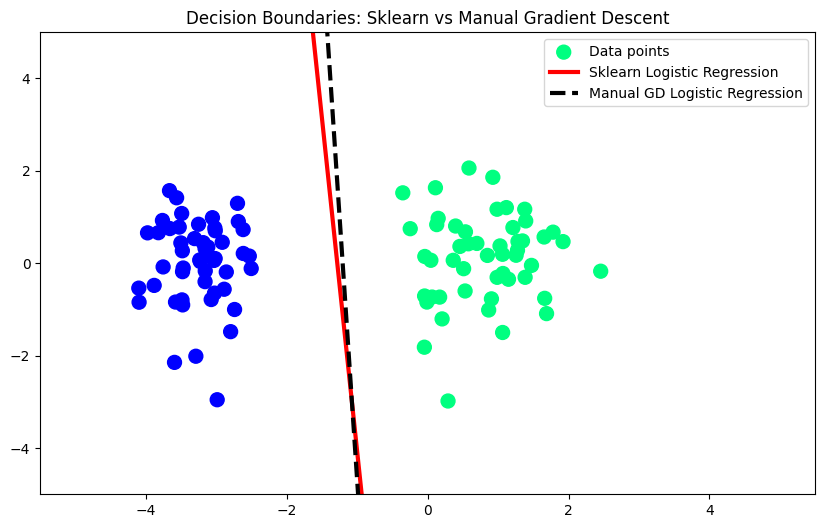

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

# 1. Generate a simple binary classification dataset
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=41,
    hypercube=False,
    class_sep=20
)

# 2. Visualize the dataset
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.title("Dataset")
plt.show()


# 3. Train Logistic Regression using sklearn (built-in / automatic)
lor = LogisticRegression(
    penalty=None,       # FIX: 'none' is invalid, None is correct
    solver='lbfgs',     # FIX: compatible solver
    max_iter=5000       # ensures convergence
)

lor.fit(X, y)

print("Sklearn coefficients (w1, w2):", lor.coef_)
print("Sklearn intercept (bias):", lor.intercept_)

# 4. Compute decision boundary for sklearn logistic regression
w1_s, w2_s = lor.coef_[0][0], lor.coef_[0][1]
b_s = lor.intercept_[0]

m1 = -(w1_s / w2_s)          # slope
c1 = -(b_s / w2_s)           # intercept

x_input = np.linspace(-5, 5, 100)
y_input = m1 * x_input + c1


# 5. Define sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# 6. Manual Gradient Descent Implementation for Logistic Regression
def gd(X, y, lr=0.5, epochs=5000):
    """
    X : (n_samples, 2)  - original features (without bias)
    y : (n_samples,)    - labels (0 or 1)
    lr: learning rate
    epochs: number of iterations
    """

    # 6.1 Add bias term as first column (all 1s)
    X_bias = np.insert(X, 0, 1, axis=1)   # shape: (n_samples, 3)

    # 6.2 Initialize weights [bias, w1, w2] as ones
    weights = np.ones(X_bias.shape[1])    # shape: (3,)

    # 6.3 Gradient ascent loop
    for i in range(epochs):
        # Linear combination: z = X_bias · weights
        z = np.dot(X_bias, weights)

        # Predicted probability using sigmoid
        y_hat = sigmoid(z)

        # Error = (actual - predicted)
        error = y - y_hat

        # Gradient of log-likelihood
        gradient = np.dot(error, X_bias) / X_bias.shape[0]

        # Update weights
        weights = weights + lr * gradient

    # Return w1, w2, bias separately
    return weights[1:], weights[0]


# 7. Get manual logistic regression weights via gradient descent
coef_manual, intercept_manual = gd(X, y, lr=0.5, epochs=5000)

print("Manual GD coefficients (w1, w2):", coef_manual)
print("Manual GD intercept (bias):", intercept_manual)


# 8. Decision boundary for manual gradient descent model
w1_m, w2_m = coef_manual[0], coef_manual[1]
b_m = intercept_manual

m2 = -(w1_m / w2_m)
c2 = -(b_m / w2_m)

x_input2 = np.linspace(-5, 5, 100)
y_input2 = m2 * x_input2 + c2


# 9. Plot dataset + both decision boundaries
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100, label="Data points")
plt.plot(x_input, y_input, color='red', linewidth=3, label='Sklearn Logistic Regression')
plt.plot(x_input2, y_input2, color='black', linewidth=3, linestyle='--', label='Manual GD Logistic Regression')
plt.ylim(-5, 5)
plt.title("Decision Boundaries: Sklearn vs Manual Gradient Descent")
plt.legend()
plt.show()
